### LISTA 2
Biblioteka pandas, statystyki: mediana, rozstęp międzykwartylowy, odchylenie standarowe itp.

In [1]:
import numpy as np
import scipy.stats as sc
import pandas as pd
import statistics
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_dict = {
    'Name': ['Alice', 'Bob', 'Jeremy'],
    'Age': ['24', '123','12'],
    'Country': ['USA', 'Canada', 'Canada']
}

df = pd.DataFrame(data_dict)
dt = pd.read_csv('C:/Users/Kacper/Downloads/Affairs.csv')
# print(dt.head()) # first 5 rows
# print(dt.tail()) # last 5 rows
# print(dt.info()) # type of data we store (inf, float, objects etc)
# print(dt.describe())
# df.columns # nazwy kolumn
# dt.index # how many rows of data you store

In [3]:
def median(X):
    X = np.sort(X)
    n = len(X)
    if n % 2 == 1:
        return X[n/2]
    return (X[n//2] + X[n//2 - 1])/2

def quartile(X):
    X = np.sort(X)
    n = len(X)
    q2 = median(X)
    q3 = median(X[n//2:])
    q1 = median(X[:n//2])
    q4 = X[n-1]
    return [q1, q2, q3, q4]

def IQR(X):
    q1, _, q3, _ = quartile(X)
    return q3 - q1

def R(X):
    return max(X) - min(X)

def variance(X):
    n = len(X)
    mean = np.mean(X)
    S = np.sum((X - mean)**2)
    return 1/(n-1)*S

def sigma(X):
    return np.sqrt(variance(X))


In [4]:
X = np.random.normal(loc=2, scale=2, size=2000)
print(f'Statistics - my functions: {median(X), quartile(X), IQR(X), R(X), variance(X), sigma(X)}')
q1 = np.quantile(X, 0.25)
q2 = np.quantile(X, 0.5)
q3 = np.quantile(X, 0.75)
q4 = np.quantile(X, 1)
print(f'Statistics - built in functions: {np.median(X), [q1, q2, q3, q4], sc.iqr(X), max(X) - min(X), np.var(X), np.std(X)}')

Statistics - my functions: (1.999667519555675, [0.6054137289335956, 1.999667519555675, 3.3218545104677935, 8.689526889741948], 2.7164407815341978, 13.280223150155962, 4.137920908517797, 2.03418802191877)
Statistics - built in functions: (1.999667519555675, [0.6079117492890349, 1.999667519555675, 3.3210353787872333, 8.689526889741948], 2.713123629498199, 13.280223150155962, 4.1358519480635385, 2.0336794113290173)


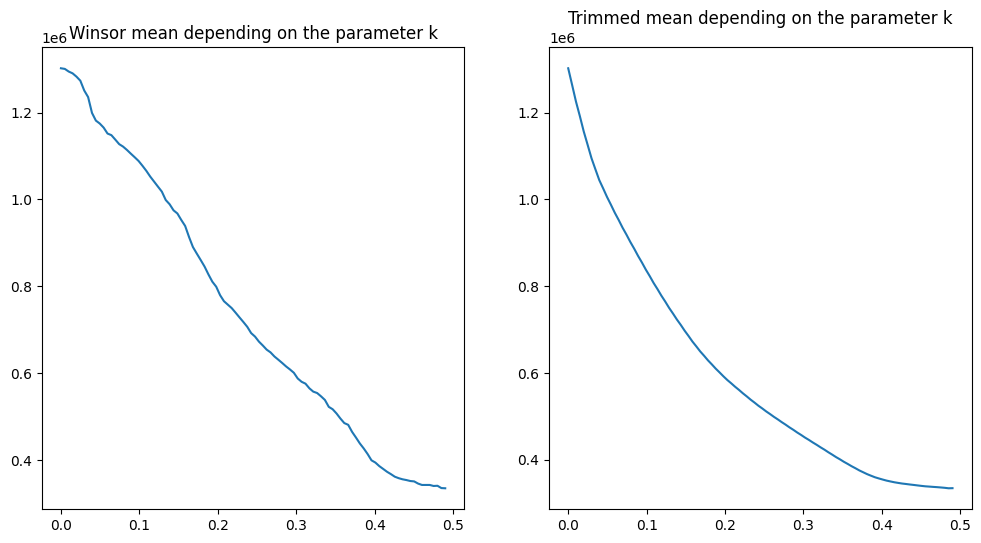

In [5]:
mean_data = pd.read_csv('C:/Users/Kacper/Downloads/nass.soybean.csv')['acres']

N = 100
k = np.linspace(0, 0.49, N)
winsor_array = np.empty(N)
trim_array = np.empty(N)

for i in range(N):
    limits = [k[i], k[i]]
    winsor = sc.mstats.winsorize(mean_data, limits=limits)
    trimmean = sc.mstats.trimmed_mean(mean_data, limits=limits)
    winsor_array[i] = np.mean(winsor)
    trim_array[i] = trimmean

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(k, winsor_array)
axs[1].plot(k, trim_array)
axs[0].set_title('Winsor mean depending on the parameter k')
axs[1].set_title('Trimmed mean depending on the parameter k')
plt.show()

In [6]:
data = pd.read_csv('C:/Users/Kacper/Downloads/Affairs.csv')
#print(data)
affairs = data['affairs']
hmean = sc.hmean(affairs)
gmeanb = sc.gmean(affairs)
mean = np.mean(affairs)
set(affairs) #  elements

data_affairs_age = data[['affairs', 'yearsmarried']]

ind_2 = data.iloc[2] # data in ith row
ind_2_affairs = data.iloc[2]['yearsmarried']


### Data filtering

In [7]:
d1 = data[(data['gender']=='female') & (data['age'] == 32)]
d2 = data[(data['gender']=='female') | (data['age'] == 32)] # or operator
d2 = data[~(data['gender']=='female')] # not operator

d4 = data[data['age'] > 32]['age']
dg = data[['affairs', 'age', 'religiousness']]

dm = data[data['age'].isin([22, 23, 24])] # search for age 22, 23 and 24
#print(dm)

### Data modification (deletion, etc)

In [8]:
#data.loc[data['rating'] == 3, 'age'] = '2'
#data = data.drop(2) # deletes second row
#data.dropna() # deletes Nan values
#data.fillna({'age': 0}, {'education': 3}) # if Nan value, implace those 

### Operations on data (group by, sum etc)

In [9]:
ct = data['affairs'].value_counts()
print(ct)
group = data.groupby('education')['affairs'].sum()

sort = data.sort_values(['age', 'affairs'], ascending=[False, True])
#print(sort)
#print(group)
#data.to_csv('new_database.csv')

affairs
0     451
7      42
12     38
1      34
3      19
2      17
Name: count, dtype: int64


### Kontynuacja listy -> Boxplot

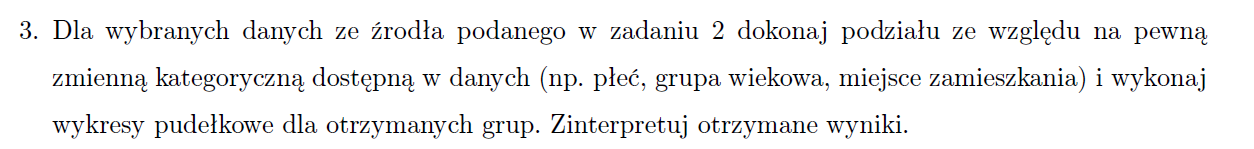

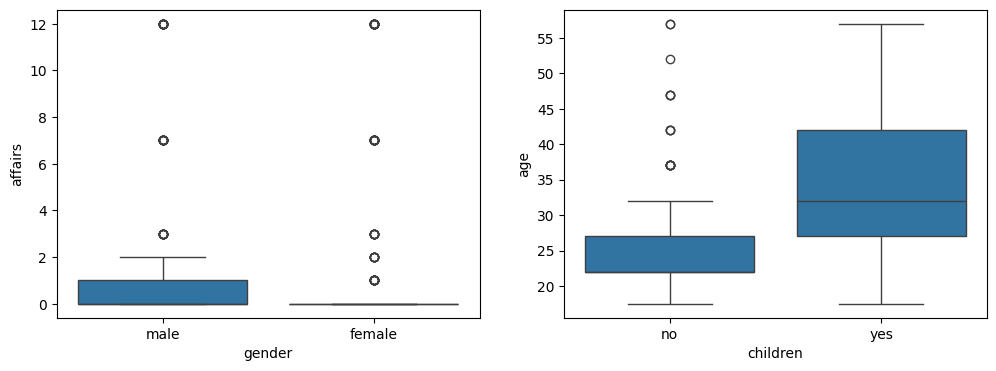

In [10]:
dt = pd.read_csv('C:/Users/Kacper/Downloads/Affairs.csv')
#print(dt.head())

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=data, x='gender', y='affairs', ax=axs[0])
sns.boxplot(data=data, x='children', y='age', ax=axs[1])
plt.show()

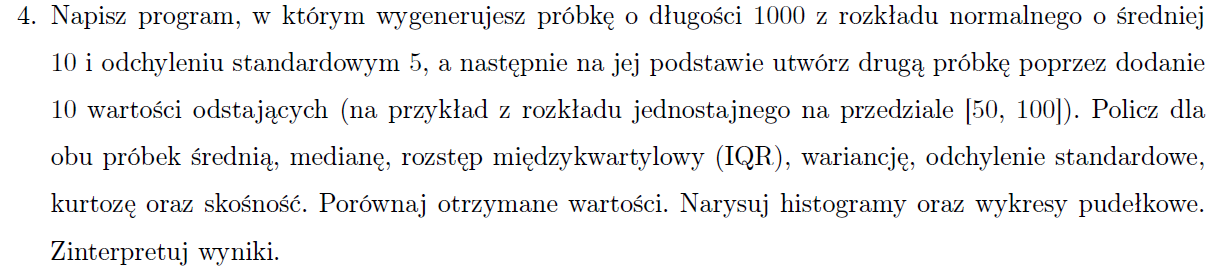

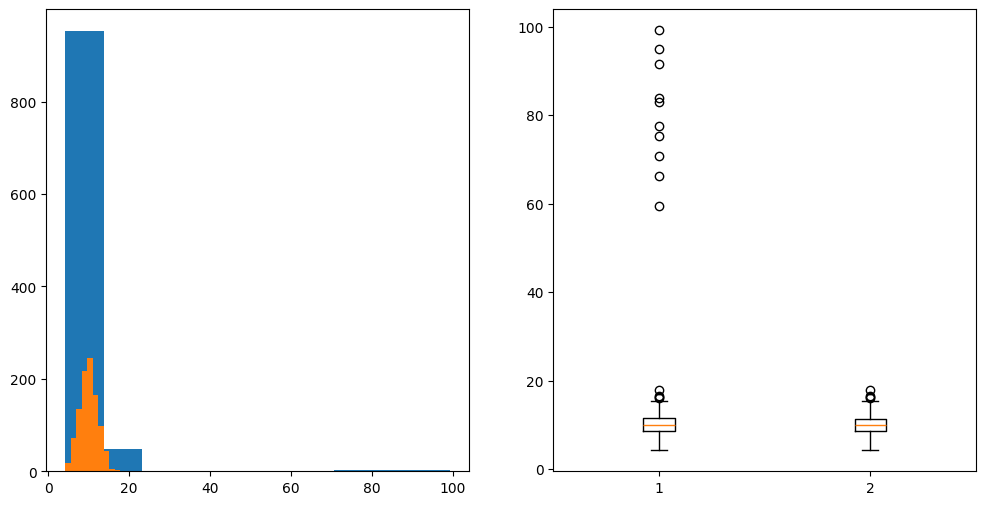

In [11]:
x_normal = np.random.normal(loc=10, scale=np.sqrt(5), size=1000)
U = np.random.random(size=10) * 50 + 50
x_new = np.array(x_normal)
x_new = np.concatenate([x_new, U])
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].hist(x_new)
axs[0].hist(x_normal)
axs[1].boxplot([x_new, x_normal])
plt.show()

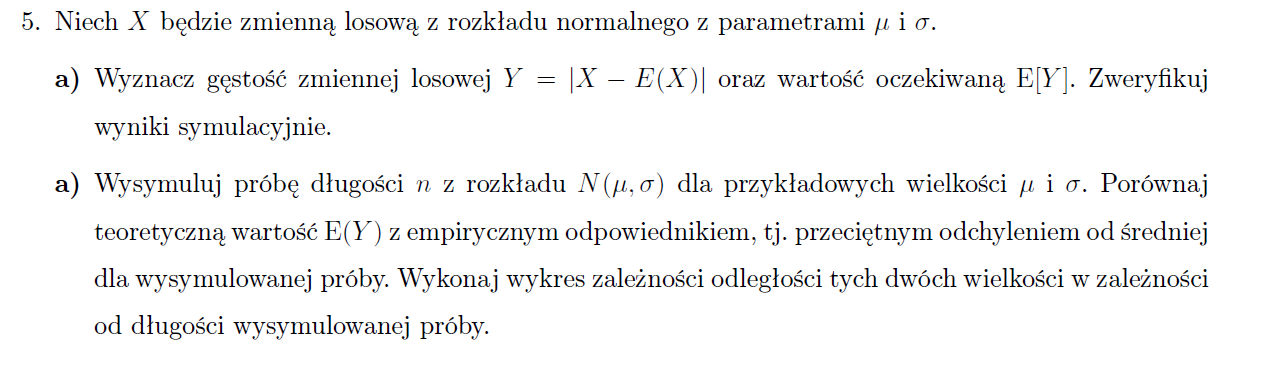

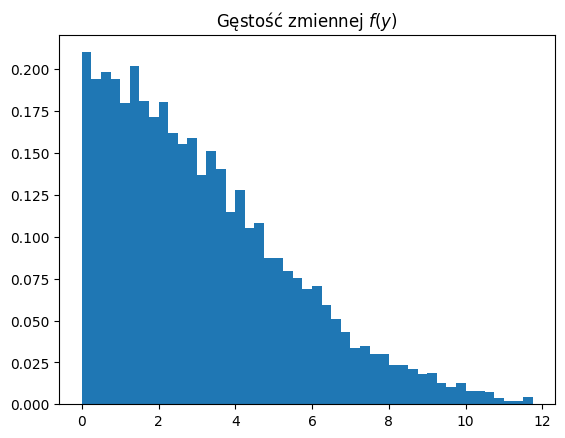

In [16]:
mu = 3
sig = 4
X = np.random.normal(loc=mu, scale=sig, size=10000)
Y = np.abs(X - np.mean(X))

plt.hist(Y, density=True, bins=np.arange(0, 12, 0.25))
plt.title("Gęstość zmiennej $f(y)$")
plt.show()

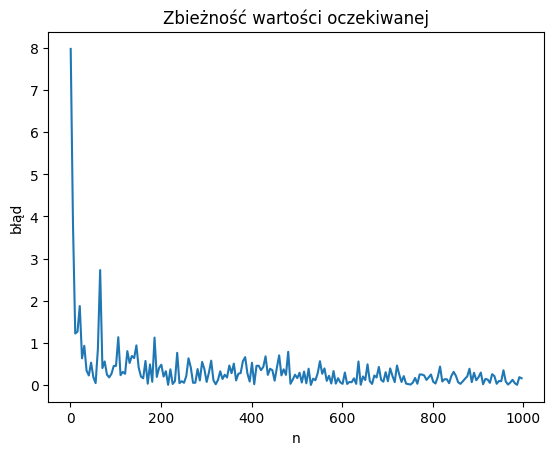

In [34]:
mu = -15
sigma = 10
y_data = []
N = np.arange(1, 1000, 5)

errors = []

for n in N:
    X = np.random.normal(mu, sigma, size=n)
    Y = np.abs(X - np.mean(X))

    empirical = np.mean(Y)
    EY = sigma * np.sqrt(2 / np.pi)

    errors.append(abs(empirical - EY))

plt.plot(N, errors)
plt.xlabel("n")
plt.ylabel("błąd")
plt.title("Zbieżność wartości oczekiwanej")
plt.show()